# 02. Pretrained LLM Inference and Text Generation

The previous notebook built a miniature GPT from scratch. This notebook moves to a pretrained causal language model and inspects the complete inference path rather than treating `generate()` as a black box.

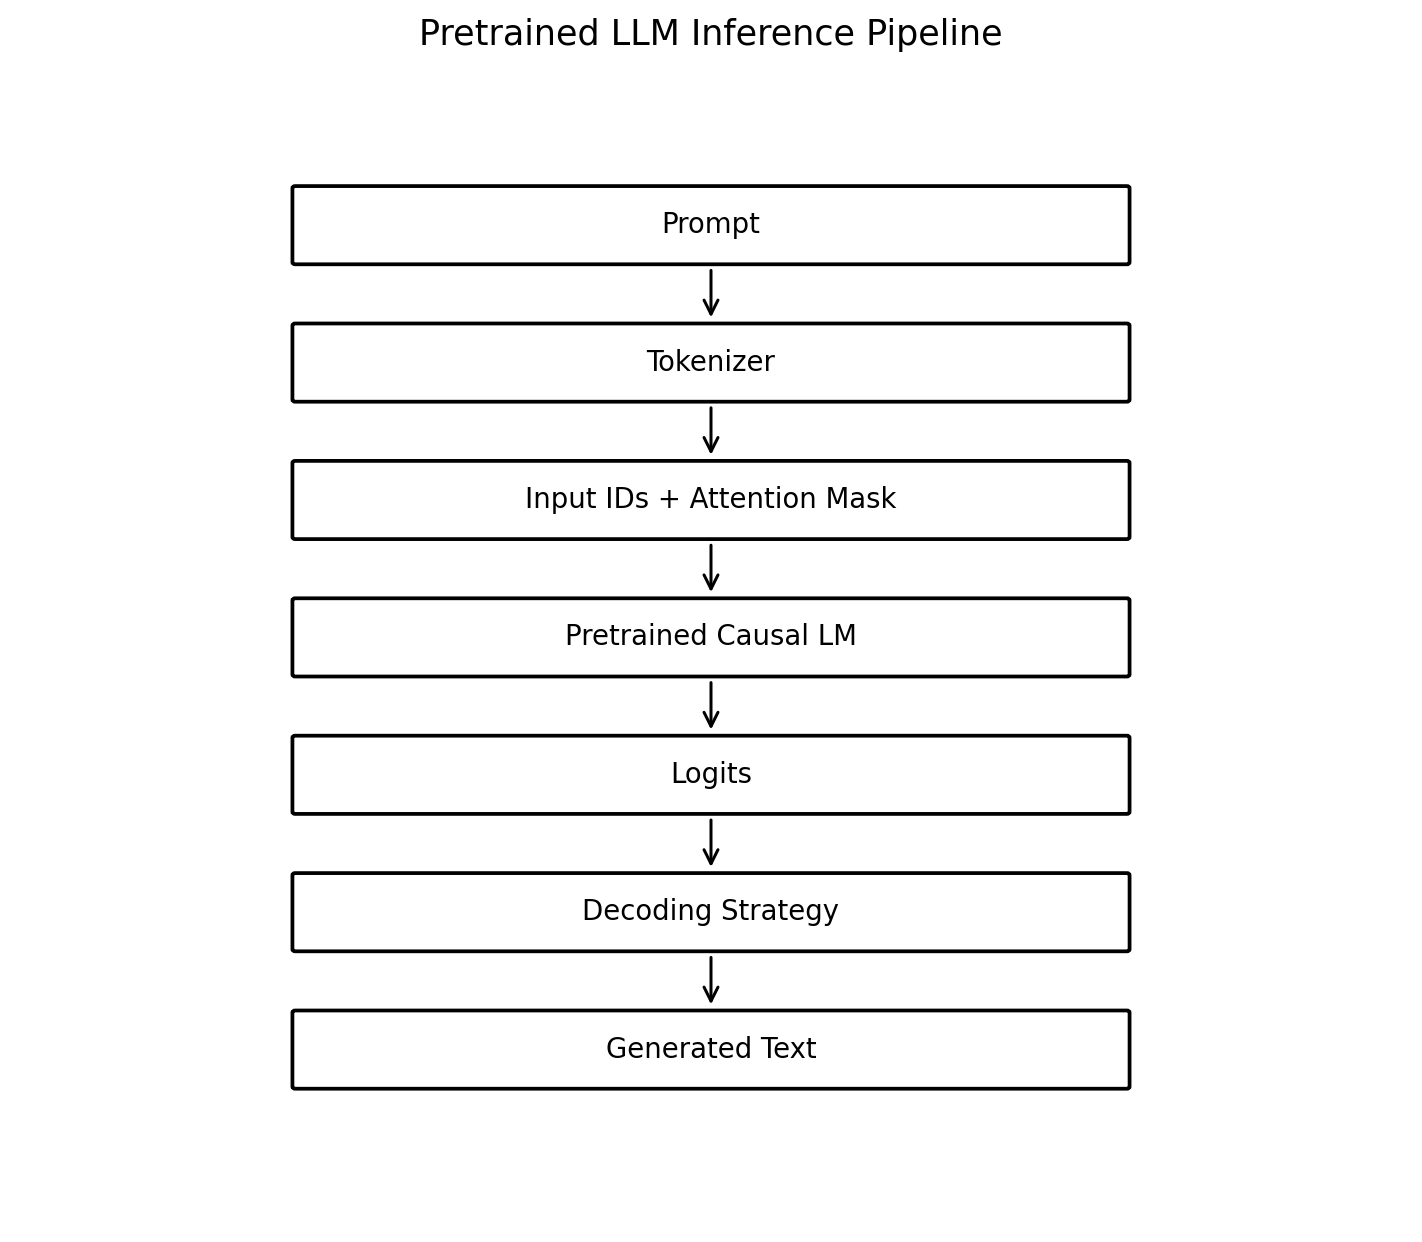

## Learning Objectives

- explain what pretraining contributes,
- inspect a modern tokenizer and subword tokens,
- understand input IDs and attention masks,
- inspect model architecture and parameter count,
- perform a forward pass and interpret the logits tensor,
- manually recover the highest-probability next token,
- compare greedy, beam, temperature, top-k, and top-p decoding,
- understand repetition control, context length, and KV caching,
- analyze why different decoding settings change generated text.

## 1. From a Mini GPT to a Pretrained Language Model

Training a useful general-purpose LLM from scratch requires enormous text corpora, compute, and distributed optimization. Pretraining transfers the expensive general language-learning stage into reusable model weights.

The main question in this notebook is therefore not simply *How do I call a model?* but:

> What are the numerical objects passed through a pretrained causal language model, and how does generation convert them into text?

## 2. Install/Import Libraries

If these packages are not already installed, run the commented installation cell once in Colab.

In [1]:
# Uncomment this line in a fresh Colab environment if needed.
# !pip install -q transformers accelerate sentencepiece

In [2]:
import math

import pandas as pd
import torch
import torch.nn.functional as F

from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer

print("PyTorch version:")
print(torch.__version__)

PyTorch version:
2.11.0+cpu


## 3. Select a Small Pretrained Causal Language Model

`distilgpt2` is compact enough for an instructional notebook while preserving the GPT-2 causal language-model interface.

In [3]:
model_name = "distilgpt2"

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Model name:")
print(model_name)

print()
print("Device:")
print(device)

Model name:
distilgpt2

Device:
cpu


## 4. Load the Tokenizer

In [4]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer class:")
print(type(tokenizer))

print()
print("Vocabulary size:")
print(tokenizer.vocab_size)

print()
print("Model maximum length reported by tokenizer:")
print(tokenizer.model_max_length)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer class:
<class 'transformers.models.gpt2.tokenization_gpt2.GPT2Tokenizer'>

Vocabulary size:
50257

Model maximum length reported by tokenizer:
1024


## 5. Inspect Subword Tokenization

Modern tokenizers may split a word into several pieces. The exact pieces depend on the tokenizer vocabulary and merge rules.

In [5]:
examples = [
    "transformer",
    "unbelievable",
    "manufacturing",
    "reinforcement learning",
    "digital twin"
]

for example in examples:
    tokens = tokenizer.tokenize(example)

    print("Text:", example)
    print("Tokens:", tokens)
    print()

Text: transformer
Tokens: ['trans', 'former']

Text: unbelievable
Tokens: ['un', 'bel', 'iev', 'able']

Text: manufacturing
Tokens: ['manufact', 'uring']

Text: reinforcement learning
Tokens: ['re', 'in', 'forcement', 'Ġlearning']

Text: digital twin
Tokens: ['digital', 'Ġtwin']



## 6. Encode and Decode a Prompt

In [6]:
prompt = "Artificial intelligence can improve manufacturing systems by"

encoded = tokenizer(
    prompt,
    return_tensors="pt"
)

print("Tokenizer output keys:")
print(encoded.keys())

print()
print("Input IDs:")
print(encoded["input_ids"])

print()
print("Attention mask:")
print(encoded["attention_mask"])

Tokenizer output keys:
KeysView({'input_ids': tensor([[8001, 9542, 4430,  460, 2987, 9138, 3341,  416]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])})

Input IDs:
tensor([[8001, 9542, 4430,  460, 2987, 9138, 3341,  416]])

Attention mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1]])


### Convert IDs Back to Tokens

In [7]:
input_ids = encoded["input_ids"][0]

tokens = tokenizer.convert_ids_to_tokens(input_ids)

print("Tokens:")
print(tokens)

print()
print("Decoded reconstruction:")
print(tokenizer.decode(input_ids))

Tokens:
['Art', 'ificial', 'Ġintelligence', 'Ġcan', 'Ġimprove', 'Ġmanufacturing', 'Ġsystems', 'Ġby']

Decoded reconstruction:
Artificial intelligence can improve manufacturing systems by


## 7. Padding and the Attention Mask

GPT-2 does not define a padding token by default. For batched generation demonstrations, a common educational choice is to reuse the end-of-sequence token as the padding token.

In [8]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Padding token:")
print(tokenizer.pad_token)

print()
print("Padding token ID:")
print(tokenizer.pad_token_id)

Padding token:
<|endoftext|>

Padding token ID:
50256


The attention mask contains `1` for real input tokens and `0` for padded positions. It tells the model which positions belong to the actual prompt.

In [9]:
batched_prompts = [
    "AI can improve manufacturing",
    "Digital twins"
]

batched = tokenizer(
    batched_prompts,
    padding=True,
    return_tensors="pt"
)

print("Batched input IDs:")
print(batched["input_ids"])

print()
print("Batched attention masks:")
print(batched["attention_mask"])

Batched input IDs:
tensor([[20185,   460,  2987,  9138],
        [27640, 20345, 50256, 50256]])

Batched attention masks:
tensor([[1, 1, 1, 1],
        [1, 1, 0, 0]])


## 8. Load the Pretrained Model

In [10]:
model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to(device)
model.eval()

print("Model class:")
print(type(model))

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model class:
<class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'>


## 9. Count Model Parameters

In [11]:
total_parameters = 0

for parameter in model.parameters():
    total_parameters = total_parameters + parameter.numel()

print("Total parameters:")
print(f"{total_parameters:,}")

Total parameters:
81,912,576


## 10. Inspect the Model Architecture

Printing the architecture reveals the repeated decoder blocks, attention modules, feed-forward layers, layer normalization, token embeddings, and language-model head.

In [12]:
print(model)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


## 11. Perform a Forward Pass Without `generate()`

A causal language model returns logits for every input position. The final position's logits represent the model's distribution over the next possible token.

In [13]:
model_inputs = tokenizer(
    prompt,
    return_tensors="pt"
)

model_inputs = {
    key: value.to(device)
    for key, value in model_inputs.items()
}

with torch.no_grad():
    outputs = model(**model_inputs)

logits = outputs.logits

print("Logits tensor shape:")
print(logits.shape)

Logits tensor shape:
torch.Size([1, 8, 50257])


For one prompt, the shape is:

`(batch_size, sequence_length, vocabulary_size)`

The model predicts a vocabulary distribution at every sequence position.

## 12. Manually Predict the Next Token

In [14]:
last_position_logits = logits[:, -1, :]

next_token_probabilities = F.softmax(
    last_position_logits,
    dim=-1
)

best_token_id = int(torch.argmax(next_token_probabilities, dim=-1))
best_token_probability = float(next_token_probabilities[0, best_token_id])

best_token = tokenizer.decode([best_token_id])

print("Predicted next-token ID:")
print(best_token_id)

print()
print("Predicted next token:")
print(repr(best_token))

print()
print("Probability:")
print(best_token_probability)

Predicted next-token ID:
10068

Predicted next token:
' improving'

Probability:
0.06868817657232285


## 13. Inspect the Top Candidate Tokens

In [15]:
number_of_candidates = 10

candidate_probabilities, candidate_ids = torch.topk(
    next_token_probabilities[0],
    k=number_of_candidates
)

rows = []

for rank in range(number_of_candidates):
    token_id = int(candidate_ids[rank])
    probability = float(candidate_probabilities[rank])
    token_text = tokenizer.decode([token_id])

    rows.append({
        "Rank": rank + 1,
        "Token ID": token_id,
        "Token": repr(token_text),
        "Probability": probability
    })

candidate_table = pd.DataFrame(rows)

candidate_table

,Rank,Token ID,Token,Probability
0,1,10068,' improving',0.068688
1,2,8868,' reducing',0.043397
2,3,3649,' increasing',0.038259
3,4,1642,' making',0.036239
4,5,1262,' using',0.031254
5,6,4955,' providing',0.024808
6,7,4441,' creating',0.020810
7,8,5086,' allowing',0.020440
8,9,15882,' enabling',0.019105
9,10,5742,' helping',0.017801


## 14. Greedy Decoding

Greedy decoding chooses the maximum-probability token at every step. It is deterministic but may become repetitive or locally optimal rather than globally fluent.

In [16]:
input_batch = tokenizer(
    prompt,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    greedy_ids = model.generate(
        **input_batch,
        max_new_tokens=60,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

print(tokenizer.decode(greedy_ids[0], skip_special_tokens=True))

Artificial intelligence can improve manufacturing systems by improving the quality of the products.























































## 15. Beam Search

Beam search maintains several candidate continuations instead of committing immediately to one path. This can improve sequence-level likelihood but is often less appropriate for open-ended creative generation.

In [17]:
with torch.no_grad():
    beam_ids = model.generate(
        **input_batch,
        max_new_tokens=60,
        num_beams=4,
        do_sample=False,
        early_stopping=True,
        pad_token_id=tokenizer.eos_token_id
    )

print(tokenizer.decode(beam_ids[0], skip_special_tokens=True))

Artificial intelligence can improve manufacturing systems by increasing the number of workers.














## 16. Temperature Sampling

Temperature rescales the logits before softmax:

$$
P_i = rac{\exp(z_i/T)}{\sum_j \exp(z_j/T)}.
$$

- low `T` makes the distribution sharper and more deterministic,
- high `T` makes it flatter and more diverse.

In [18]:
temperatures = [0.3, 0.7, 1.2]

for temperature in temperatures:
    with torch.no_grad():
        generated_ids = model.generate(
            **input_batch,
            max_new_tokens=60,
            do_sample=True,
            temperature=temperature,
            top_k=50,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    print("Temperature:", temperature)
    print(generated_text)
    print("-" * 80)

Temperature: 0.3
Artificial intelligence can improve manufacturing systems by reducing the number of jobs created by artificial intelligence.


















































--------------------------------------------------------------------------------
Temperature: 0.7
Artificial intelligence can improve manufacturing systems by using artificial intelligence. Instead of the human being being, the artificial intelligence is simply smarter than humans.








































--------------------------------------------------------------------------------
Temperature: 1.2
Artificial intelligence can improve manufacturing systems by creating cheaper, cheaper and more efficient ones, in the end. This way, manufacturers could compete for better, faster, and more valuable technology, with many important benefits and costs. This is good news for many industries that have the most efficient manufacturing process, with a strong track record and solid knowledg

## 17. Top-k Sampling

Top-k sampling limits the candidate set to the `k` highest-scoring tokens before sampling.

In [19]:
top_k_values = [10, 40, 100]

for top_k in top_k_values:
    with torch.no_grad():
        generated_ids = model.generate(
            **input_batch,
            max_new_tokens=60,
            do_sample=True,
            temperature=0.8,
            top_k=top_k,
            pad_token_id=tokenizer.eos_token_id
        )

    print("Top-k:", top_k)
    print(tokenizer.decode(generated_ids[0], skip_special_tokens=True))
    print("-" * 80)

Top-k: 10
Artificial intelligence can improve manufacturing systems by improving the efficiency of production, and the performance of products.




The next generation of advanced manufacturing systems will be built in the United States, with the goal of improving manufacturing efficiency and efficiency.

In this post, we will look at three major technologies that will improve manufacturing efficiency
--------------------------------------------------------------------------------
Top-k: 40
Artificial intelligence can improve manufacturing systems by introducing a new approach to the problem, with an approach that includes a series of "smart" devices that can be customized to be used to produce the desired product.






The company has partnered with Google to develop a prototype device with a high level of accuracy, in hopes
--------------------------------------------------------------------------------
Top-k: 100
Artificial intelligence can improve manufacturing systems by using an

## 18. Top-p / Nucleus Sampling

Top-p sampling chooses the smallest set of tokens whose cumulative probability reaches a threshold `p`. The candidate-set size therefore changes dynamically at each generation step.

In [20]:
top_p_values = [0.70, 0.90, 0.95]

for top_p in top_p_values:
    with torch.no_grad():
        generated_ids = model.generate(
            **input_batch,
            max_new_tokens=60,
            do_sample=True,
            temperature=0.8,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id
        )

    print("Top-p:", top_p)
    print(tokenizer.decode(generated_ids[0], skip_special_tokens=True))
    print("-" * 80)

Top-p: 0.7
Artificial intelligence can improve manufacturing systems by increasing the number of jobs and saving money.



















































--------------------------------------------------------------------------------
Top-p: 0.9
Artificial intelligence can improve manufacturing systems by using intelligent design and technology that enables the user to design and integrate their own systems and software, and the ability to build their own systems.
--------------------------------------------------------------------------------
Top-p: 0.95
Artificial intelligence can improve manufacturing systems by increasing production capacity.
























































--------------------------------------------------------------------------------


## 19. Repetition Penalty

Open-ended causal models can fall into repetitive loops. Repetition penalties adjust the scores of tokens that have already appeared.

In [21]:
with torch.no_grad():
    repetition_control_ids = model.generate(
        **input_batch,
        max_new_tokens=80,
        do_sample=True,
        temperature=0.8,
        top_p=0.92,
        repetition_penalty=1.15,
        pad_token_id=tokenizer.eos_token_id
    )

print(tokenizer.decode(repetition_control_ids[0], skip_special_tokens=True))

Artificial intelligence can improve manufacturing systems by improving the performance of a machine.
The world's fastest growing digital-art market is being driven largely by artificial intelligence and computer vision, according to data analysis from Thomson Reuters' research firm Intelligence Analytics (ING). The latest survey shows that most companies are planning on investing in autonomous robotic agents for use in new products or services such as robotics. Companies interested in robots may be able provide tools more


## 20. Structured Comparison of Decoding Methods

In [22]:
decoding_summary = pd.DataFrame({
    "Method": [
        "Greedy",
        "Beam Search",
        "Temperature Sampling",
        "Top-k Sampling",
        "Top-p Sampling"
    ],
    "Main Idea": [
        "Choose the highest-probability next token",
        "Keep several candidate sequences",
        "Rescale distribution sharpness",
        "Sample from the k highest-scoring tokens",
        "Sample from a cumulative-probability nucleus"
    ],
    "Typical Behavior": [
        "Deterministic, may repeat",
        "Structured, sequence-likelihood focused",
        "Adjustable randomness",
        "Controlled candidate set",
        "Adaptive diversity"
    ]
})

decoding_summary

,Method,Main Idea,Typical Behavior
0,Greedy,Choose the highest-probability next token,"Deterministic, may repeat"
1,Beam Search,Keep several candidate sequences,"Structured, sequence-likelihood focused"
2,Temperature Sampling,Rescale distribution sharpness,Adjustable randomness
3,Top-k Sampling,Sample from the k highest-scoring tokens,Controlled candidate set
4,Top-p Sampling,Sample from a cumulative-probability nucleus,Adaptive diversity


## 21. Context Length

A causal model can only condition on tokens that fit inside its supported context window. If the prompt plus generated continuation exceeds that window, earlier information must be truncated, summarized, retrieved again, or handled with a model that supports a longer context.

In [23]:
print("Maximum model positions:")
print(model.config.n_positions)

print()
print("Embedding dimension:")
print(model.config.n_embd)

print()
print("Number of transformer layers:")
print(model.config.n_layer)

print()
print("Number of attention heads:")
print(model.config.n_head)

Maximum model positions:
1024

Embedding dimension:
768

Number of transformer layers:
6

Number of attention heads:
12


## 22. KV Cache: Why Autoregressive Generation Can Be Faster

During generation, the prompt does not change except for the newly appended token. Recomputing every key and value tensor from scratch would waste work.

A **key-value (KV) cache** stores previously computed attention keys and values so subsequent generation steps can reuse them.

Conceptually:

```text
Without cache: recompute K,V for old tokens at every step
With cache:    compute K,V only for the new token and reuse old K,V
```

This reduces repeated computation, though the cache itself consumes memory that grows with sequence length, layer count, head count, and hidden dimension.

## 23. Inspect Whether Generation Uses a Cache

In [24]:
print("use_cache configuration:")
print(model.config.use_cache)

use_cache configuration:
True


## 24. Hallucination and Model Knowledge

A pretrained language model generates statistically plausible token sequences. Plausibility is not the same as factual correctness.

Important limitations include:

- outdated or incomplete knowledge,
- confident fabrication,
- sensitivity to wording,
- lack of source attribution by default,
- inability to verify external facts unless connected to tools or retrieval.

These limitations motivate fine-tuning for task adaptation and RAG for external knowledge grounding.

## 25. Connection to the Next Notebook

This notebook used frozen pretrained weights. The next notebook asks:

> How can we adapt a pretrained model to a task without updating every parameter?

That leads to full fine-tuning, parameter-efficient fine-tuning, and LoRA.

## Key Takeaways

1. A tokenizer converts text into subword token IDs and attention masks.
2. A causal LLM produces one vocabulary-logit vector per sequence position.
3. The last-position logits define the next-token distribution.
4. `generate()` repeatedly performs inference and decoding; it is not a separate learned model.
5. Greedy, beam, temperature, top-k, and top-p decoding produce different trade-offs.
6. Context length constrains how much prior information the model can condition on directly.
7. KV caching reduces repeated autoregressive attention computation.
8. Pretraining gives broad capability but does not guarantee factual or task-specific behavior.